## Deep Learning

**Developer:** Ayansewa Adedeji

Course: Artificial Intelligence Applications

Program Requirements:
1. Describe **"Deep Learning"**
2. Describe **"Neural Networks"**
3. Install necessary modules/packages
4. Import required datasets
5. Analyze images
6. Build and train convolutional neural network (CNN) to classify images

In [1]:
# 1. necessary imports
import sys
import os
import numpy as np
import pandas as pd

print(sys.version)  # print python version
print(os.environ['CONDA_DEFAULT_ENV'])  # print conda environment

# check TensorFlow installation
import tensorflow as tf
print(tf.__version__)

# check available TensorFlow devices, and available GPU cards
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

3.9.21 (main, Dec 11 2024, 16:35:24) [MSC v.1929 64 bit (AMD64)]
testenv
2.19.0
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 15915836764010667377
xla_global_id: -1
]


In [2]:
# 2.TensorFlow installed, import Keras
# Load built-in dataset (cifar10) from keras module/package
# Note: keras includes other datasets as well.
from tensorflow import keras
from keras.datasets import cifar10
import matplotlib.pyplot as plt

In [3]:
# 3. 
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [4]:
# 4. Load data and split datasets
# instead of usual split data format:
# (train_x,train_y),(test_x,test_y)=cifar10.load_data()
# following variables are used for clarity
(train_images,train_labels),(test_images,test_labels)=cifar10.load_data()

# dimensions in percentages
total = train_images.shape[0] + test_images.shape[0]

# String format() method:
# https://docs.python.org/3/tutorial/inputoutput.html#the-string-format-method
print("\n{0} {1:.2f}%".format("train_images percentage:", (train_images.shape[0]/total)*100))
print("{0} {1:.2f}%".format("test_images percentage:", (test_images.shape[0]/total)*100))


train_images percentage: 83.33%
test_images percentage: 16.67%


In [5]:
# 5. display training images shape
# Note: 50,000 images, 32X32px, and three color channels (RGB)
train_images.shape

(50000, 32, 32, 3)

In [6]:
# 6. display number of training labels (note: matches number of images)
len(train_labels)

50000

In [7]:
# 7. display portion of training label values (note: between 0 and 9, inclusive)
train_labels

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [8]:
# 8. display test images shape
# Note: 10,000 images, 32X32px, and three color channels (RGB)
test_images.shape

(10000, 32, 32, 3)

In [9]:
# 9. correspondingly, display number of test labels (note: matches number of images)
len(test_labels)

10000

In [10]:
# 10. display portion of test label values (note: between 0 and 9, inclusive)
test_labels

array([[3],
       [8],
       [8],
       ...,
       [5],
       [1],
       [7]], dtype=uint8)

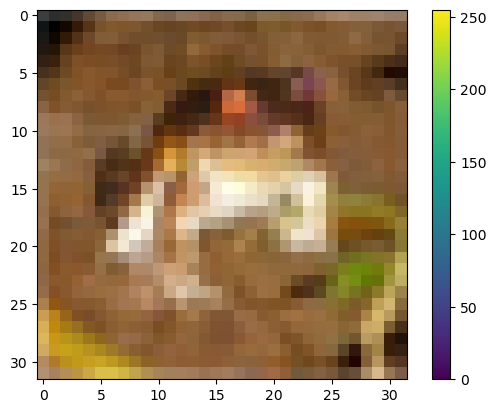

In [11]:
# 11. display preprocessed data sample
# Note: displays 32x32 pixel values, and RGB values between 0 and 255
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

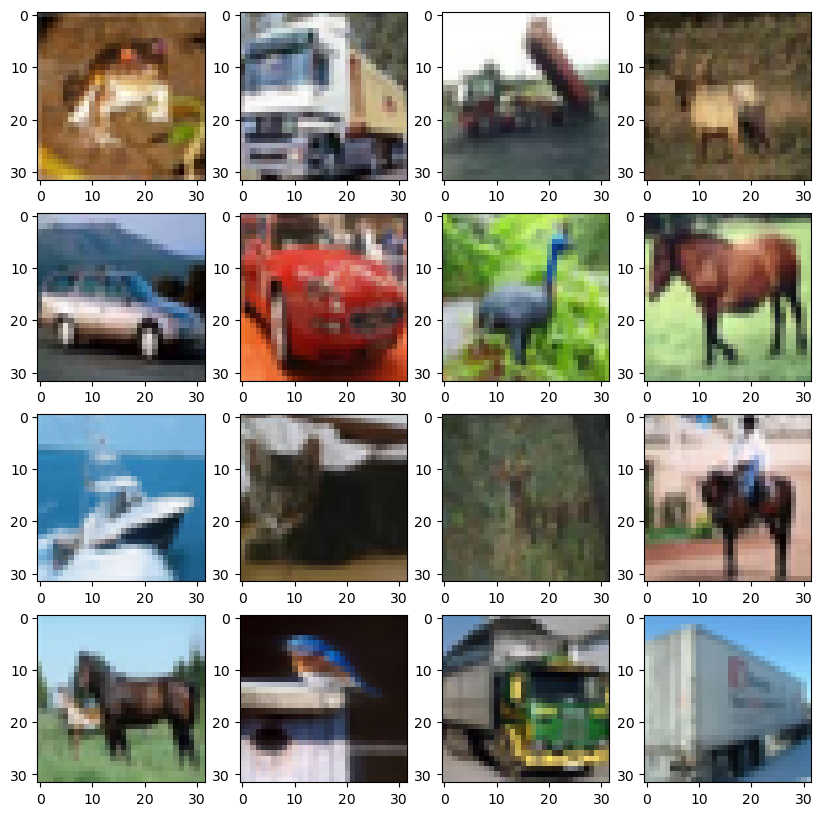

In [12]:
# 12. Plot some preprocessed images from dataset for visualization purposes
# Visualize images using loop and matplotlib subplot for display
n = 16

# define figure
fig = plt.figure(figsize = (10, 10))
for i in range(n):
    # add subplot (layout 4, 4, i+1)
    # Note: nrows=4, ncols=4, index_location = i+1
    ax = fig.add_subplot(4, 4, i+1)
    
    # train_images[i]: Image object at each iteration
    ax.imshow(train_images[i])

In [13]:
# 13. Import required layers and modules to create basic convolution neural network (CNN) architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Dropout, Flatten
from tensorflow.keras.constraints import MaxNorm
from tensorflow.keras.optimizers import SGD
from keras import utils

In [14]:
# 14. convert and display dataset pixel values using float data type (display each RGB pixel value set)
# converts pixels to float values (0-255) representing RGB values
train_images = train_images.astype('float32')
test_images = test_images.astype('float32')

train_images

array([[[[ 59.,  62.,  63.],
         [ 43.,  46.,  45.],
         [ 50.,  48.,  43.],
         ...,
         [158., 132., 108.],
         [152., 125., 102.],
         [148., 124., 103.]],

        [[ 16.,  20.,  20.],
         [  0.,   0.,   0.],
         [ 18.,   8.,   0.],
         ...,
         [123.,  88.,  55.],
         [119.,  83.,  50.],
         [122.,  87.,  57.]],

        [[ 25.,  24.,  21.],
         [ 16.,   7.,   0.],
         [ 49.,  27.,   8.],
         ...,
         [118.,  84.,  50.],
         [120.,  84.,  50.],
         [109.,  73.,  42.]],

        ...,

        [[208., 170.,  96.],
         [201., 153.,  34.],
         [198., 161.,  26.],
         ...,
         [160., 133.,  70.],
         [ 56.,  31.,   7.],
         [ 53.,  34.,  20.]],

        [[180., 139.,  96.],
         [173., 123.,  42.],
         [186., 144.,  30.],
         ...,
         [184., 148.,  94.],
         [ 97.,  62.,  34.],
         [ 83.,  53.,  34.]],

        [[177., 144., 116.],
       

In [15]:
# 15. display normalized pixel values
# normalization: constrain train and test dataset values between 0-1
train_images = train_images / 255.0
test_images = test_images / 255.0

train_images

array([[[[0.23137255, 0.24313726, 0.24705882],
         [0.16862746, 0.18039216, 0.1764706 ],
         [0.19607843, 0.1882353 , 0.16862746],
         ...,
         [0.61960787, 0.5176471 , 0.42352942],
         [0.59607846, 0.49019608, 0.4       ],
         [0.5803922 , 0.4862745 , 0.40392157]],

        [[0.0627451 , 0.07843138, 0.07843138],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509805, 0.21568628],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117648, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215687, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941177, 0.19607843],
         [0.47058824, 0.32941177, 0.19607843],
         [0.42745098, 0.28627452, 0.16470589]],

        ...,

        [[0.8156863 , 0.6666667 , 0.3764706 ],
         [0.7882353 , 0.6       , 0.13333334]

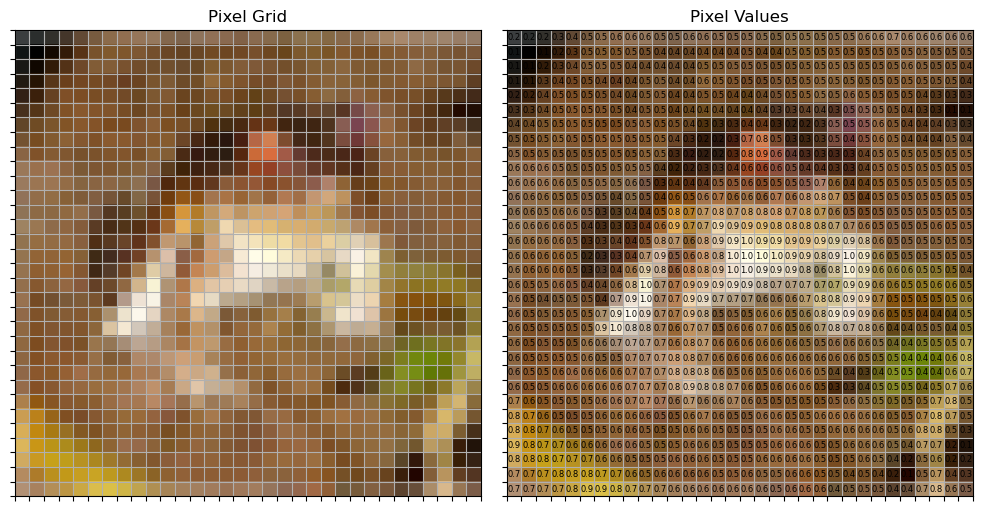

In [16]:
## Image and grid of pixels
img = train_images[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# LEFT: image with grid
axes[0].imshow(img, cmap='gray')
axes[0].grid(True)
axes[0].set_title("Pixel Grid")
axes[0].set_xticks(np.arange(-.5, 32, 1))
axes[0].set_yticks(np.arange(-.5, 32, 1))
axes[0].set_xticklabels([])
axes[0].set_yticklabels([])

# RIGHT: image with pixel values
axes[1].imshow(img, cmap='gray')
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        axes[1].text(j, i, f"{img[i, j, 0]:.1f}",
                     ha='center', va='center', fontsize=6)
axes[1].grid(True)
axes[1].set_title("Pixel Values")
axes[1].set_xticks(np.arange(-.5, 32, 1))
axes[1].set_yticks(np.arange(-.5, 32, 1))
axes[1].set_xticklabels([])
axes[1].set_yticklabels([])

plt.tight_layout()
plt.show()

In [17]:
#16. Disp,ay target class values before "one-hot encoding"
test_labels

array([[3],
       [8],
       [8],
       ...,
       [5],
       [1],
       [7]], dtype=uint8)

In [18]:
# 17. perform "one-hot encoding" for target classes and display output
# Note: "One-hot encoding" technique used to represent categorical variables as numerical values.
# Categorical variables must be changed in pre-processing section, since machine learning models require numeric input variables.
# to_categorical() function: Converts a class vector (integers) to binary class matrix.
train_labels = utils.to_categorical(train_labels)
test_labels = utils.to_categorical(test_labels)

test_labels

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]])

In [19]:
# 18. Display number of classes
num_classes=test_labels.shape[1] 
num_classes

10

## Deep Learning Models

In [20]:
# 19. create sequential model and add layers (*carefully* review documentation above)
# https://www.tensorflow.org/tutorials/keras/classification#use_the_trained_model

# define input shape
# Note: "channels" refers to image, RGB image = 3 (red, green, blue); gray image = 1
model = Sequential()  # create Sequential model
input_shape = (32,32,3)  # (height, width, channels)
model.add(Input(shape=input_shape, dtype=tf.float32))  # add input layer

# kernel_constraint: Limits magnitude (or range) of kernel weights during training; prevents overfitting and improves model
# padding='same': Used in convolutional layers to make output size equal to input size
# Convolutional layers
model.add(Conv2D(32,(3,3), padding='same', activation='relu', kernel_constraint=tf.keras.constraints.max_norm(3)))
model.add(Dropout(0.2))
model.add(Conv2D(32,(3,3), activation='relu', padding='same', kernel_constraint=tf.keras.constraints.max_norm(3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flattening and dense layers
model.add(Flatten())
model.add(Dense(512, activation='relu', kernel_constraint=tf.keras.constraints.max_norm(3)))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))  # output layer for 10 classes

In [21]:
# 20. compile model
# Optimizer: How model is updated, based on input data and its loss function.
# Loss function: Measures model's accuracy during training.
# Metrics: Used to monitor training and testing steps (above uses "accuracy," that is, fraction of images that are correctly classified.)
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [22]:
# 21. view model summary
# summary(): displays table with model layers, output shape of each layer, and number of parameters in each layer.
# https://saturncloud.io/blog/what-is-tensorflow-show-model-summary/
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       4,194,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,210,090 (16.06 MB)

 Trainable params: 4,210,090 (16.06 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# %%time
# magic command documentation: https://ipython.readthedocs.io/en/stable/interactive/magics.html#magic-time
# http://ipython.org/ipython-doc/dev/interactive/tutorial.html#magic-functions
# CPU Times vs. Wall Time: https://www.techarget.com/whatis/definition/wall-time-real-world-time-or-wall-clock-time?offer_abt_pubpro_AI_Insider

# 22. train model (Take a shower, grab some coffee, go shopping...and, it *may* be completed when you return! :)
# ALL kidding aside, this particular assignment illustrates why GPUs are generally used in AI, machine, and deep Learning vs. CPUs.
# Keras model.fit() arguments explained: https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit
# https://www.simplilearn.com/tutorials/machine-learning-tutorial/what-is-epoch-in-machine-learning

# get model training time based upon selected parameters
# https://docs.python.org/3/library/time.html#time.time
import time
start_time = time.time()

model.fit(train_images, train_labels, validation_data=(test_images,test_labels), epochs=10, batch_size=32)

end_time = time.time()
print("\nTraining time (minutes)=", format((end_time - start_time)/60, '.2f'))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 54ms/step - accuracy: 0.3909 - loss: 1.6750 - val_accuracy: 0.6178 - val_loss: 1.1094
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 98s 62ms/step - accuracy: 0.5988 - loss: 1.1255 - val_accuracy: 0.6523 - val_loss: 0.9836
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 94s 60ms/step - accuracy: 0.6505 - loss: 0.9990 - val_accuracy: 0.6688 - val_loss: 0.9536
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 102s 65ms/step - accuracy: 0.6631 - loss: 0.9424 - val_accuracy: 0.6801 - val_loss: 0.9191
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 61ms/step - accuracy: 0.6852 - loss: 0.8901 - val_accuracy: 0.6762 - val_loss: 0.9386
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 93s 59ms/step - accuracy: 0.7038 - loss: 0.8359 - val_accuracy: 0.6913 - val_loss: 0.8884
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 56ms/step - accuracy: 0.7159 - loss: 0.7956 - val_accuracy: 0.6919 - val_loss: 0.8859
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 56ms/step - accuracy: 0.7342 

In [24]:
# 23. calculate accuracy on test data
# Keras model.evaluate() arguments explained: https://www.tensorflow.org/api_docs/python/tf/keras/Model#evaluate
_, acc = model.evaluate(test_images, test_labels)
print(acc*100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7073 - loss: 0.8483
70.24999856948853


In [25]:
# 24. save model
# SavedModels are able to save custom objects (like subclasses models and custom layers), without requiring original code.
# https://tensorflow.rstudio.com/tutorials/keras/save_and_load
# https://www.tensorflow.org/tutorials/keras/save_and_load
# saves model's architecture, weights, and training configuration in a single file
model.save('my_model.keras')

In [26]:
# 25. create dictionary to map output classes, in order to make predictions from model
results = {
    0: 'aeroplane',
    1: 'automobile',
    2: 'bird',
    3: 'cat',
    4: 'deer',
    5: 'dog',
    6: 'frog',
    7: 'horse',
    8: 'ship',
    9: 'truck'
}

In [27]:
# 26. import your "own" image to test--*must* be in shape of dataset (i.e., 32,32,3)
# height, width, dimensions (i.e., number of color channels - 3 for RGB)
# use image-editing software to size images to 32px X 32px dimensions

# import PIL (Python Imaging Library)
# https://pillow.readthedocs.io/en/stable/
from PIL import Image
import numpy as np

# your image file path here--use "img" subdirectory, and .png (lossless) image file format
im = Image.open("img/parakeet.png")

# confirm 32px X 32px dimensions
# https://pillow.readthedocs.io/en/stable/reference/Image.html#PIL.Image.Image.resize
im = im.resize((32,32))

# *Even though* only *one* image is being tested, still needs to be added to a list.
# numpy.expand_dims(): Insert new axis that will appear at axis position in expanded array shape.
# https://numpy.org/doc/stable/reference/generated/numpy.expand_dims.html
im = np.expand_dims(im, axis=0)  # 2 args: 1) array expanded (im), and 2) new axis position (0), i.e., first
im = np.array(im)
type(im)  # print type

numpy.ndarray

In [28]:
# 27. numpy shape(): display number of elements (1), height, width, and number of color channels [number of elements, rows, cols, channels]
print(im.shape)

(1, 32, 32, 3)


In [29]:
# 28. verify predictions
# keras model.predict(): https://www.tensorflow.org/api_docs/python/tf/keras/Model#predict
pred = model.predict(im)

# numpy.argmax(): Returns indices of maximum values along an axis.
# https://numpy.org/doc/stable/reference/generated/numpy.argmax.html
classification = np.argmax(pred)

# display predicted classification for image
# debugging resource: https://medium.com/data-science/understanding-tensors-learning-a-data-structure-through-3-pesky-errors-d6674776be0c
print(pred, results[classification])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
[[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]] bird
